# Experiment — Feature ablation: with vs without engineered features

**Category:** feature_engineering | **Task 6** (evaluate impact of engineered features)

Notebook 02 added four engineered flags (Morning_Peak, Evening_Peak, Is_Weekend, Is_Working_Day). Do they actually help? We train every candidate **with** and **without** them and compare 5-fold CV — testing the assumption rather than trusting it.

In [1]:
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
REPO = Path.cwd()
while not (REPO / 'data').exists() and REPO != REPO.parent:
    REPO = REPO.parent
FIGS = REPO / 'reports' / 'figures'; FIGS.mkdir(parents=True, exist_ok=True)
PROC = REPO / 'data' / 'processed'
print('repo:', REPO)

repo: /home/winzer/code/python/class/aion-gridload


In [2]:
df = pd.read_csv(PROC / 'grid_load_features.csv')
TARGET = 'GridLoad_MW'
engineered = ['Morning_Peak','Evening_Peak','Is_Weekend','Is_Working_Day']
base_cols = [c for c in df.columns if c not in engineered + [TARGET]]
print('base features   :', base_cols)
print('engineered added:', engineered)

base features   : ['Hour', 'DayOfWeek', 'Temperature_C', 'Humidity_pct', 'Rainfall_mm', 'PopulationIndex', 'IndustrialIndex', 'SolarGenerationIndex', 'Region_Encoded']
engineered added: ['Morning_Peak', 'Evening_Peak', 'Is_Weekend', 'Is_Working_Day']


## Two feature sets
`base` = raw predictors + region code; `full` = base + the 4 engineered flags.

In [3]:
y = df[TARGET]
X_base = df[base_cols]
X_full = df[base_cols + engineered]
print('base:', X_base.shape, '| full:', X_full.shape)

base: (1480, 9) | full: (1480, 13)


## Candidate models (same shortlist as notebook 03)

In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
def candidates():
    return {
        'LinearRegression': Pipeline([('s', StandardScaler()), ('m', LinearRegression())]),
        'Ridge': Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=1.0))]),
        'DecisionTree': DecisionTreeRegressor(max_depth=8, random_state=42),
        'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
        'GradientBoosting': GradientBoostingRegressor(random_state=42),
    }

## 5-fold CV RMSE: base vs full

In [5]:
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
def cv_rmse(model, Xset):
    return -cross_val_score(model, Xset, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1).mean()

rows = {}
for name in candidates():
    rows[name] = {'base_RMSE': cv_rmse(candidates()[name], X_base),
                  'full_RMSE': cv_rmse(candidates()[name], X_full)}
abl = pd.DataFrame(rows).T
abl['improvement'] = abl['base_RMSE'] - abl['full_RMSE']   # positive = engineered features helped
abl['improvement_%'] = (abl['improvement'] / abl['base_RMSE'] * 100)
abl = abl.sort_values('improvement', ascending=False).round(3)
abl

/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


,base_RMSE,full_RMSE,improvement,improvement_%
Ridge,20.987,18.524,2.463,11.735
LinearRegression,20.987,18.524,2.463,11.734
DecisionTree,34.080,33.168,0.912,2.676
RandomForest,23.492,23.109,0.383,1.631
GradientBoosting,16.004,15.994,0.010,0.065


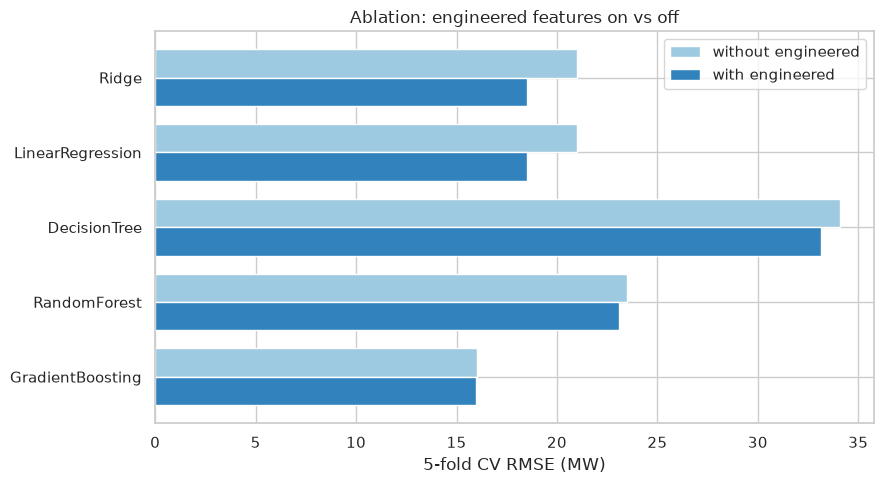

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
idx = np.arange(len(abl)); w = 0.38
ax.barh(idx - w/2, abl['base_RMSE'], w, label='without engineered', color='#9ecae1')
ax.barh(idx + w/2, abl['full_RMSE'], w, label='with engineered', color='#3182bd')
ax.set_yticks(idx); ax.set_yticklabels(abl.index); ax.invert_yaxis()
ax.set_xlabel('5-fold CV RMSE (MW)'); ax.set_title('Ablation: engineered features on vs off'); ax.legend()
fig.tight_layout(); fig.savefig(FIGS/'ablation_base_vs_full.png', dpi=120); plt.show()

## Finding

The `improvement` column is the RMSE removed by adding the four engineered flags. The result splits by model type:

- **Linear models benefit a lot** — Linear/Ridge improve ~2.5 MW RMSE (**~12%**, 21.0 → 18.5). A linear model can't express the nonlinear peak-hour effect from raw `Hour`; the explicit Morning/Evening/weekend flags hand it that structure.
- **Tree models barely move** — GradientBoosting +0.06%, RandomForest +1.6%, DecisionTree +2.7%. Trees already split on raw `Hour`/`DayOfWeek`, so the flags are largely redundant for them.

**Conclusion (Task 6):** the engineered features are genuinely valuable — but mainly as a way to give *linear* models the nonlinear calendar signal that trees discover on their own. Since our chosen model is GradientBoosting, they add little to the final score, yet we **keep them**: they don't hurt, they aid interpretability, and they make the linear baselines competitive. The dominant signal still lives in IndustrialIndex/PopulationIndex (notebooks 03/04).
